Predict electricity demand and simulate grid balance between
Germany, France, and Belgium.

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt    
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler    

In [9]:
import pandas as pd

df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")
df.head(20)

,utc_timestamp,cet_cest_timestamp,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,BE_wind_onshore_generation_actual,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,...,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile,FR_load_actual_entsoe_transparency,FR_load_forecast_entsoe_transparency,FR_solar_generation_actual,FR_wind_onshore_generation_actual
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,667.0,NaN,NaN,27246.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,9484.0,9897.0,NaN,NaN,NaN,NaN,41151.0,39723.0,...,667.0,517.0,0.7744,27246.0,8336.0,0.3059,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,9152.0,9521.0,NaN,734.81,518.66,216.15,40135.0,38813.0,...,667.0,514.0,0.7710,27246.0,8540.0,0.3134,69773.0,69750.0,NaN,1464.0
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,8799.0,9135.0,NaN,766.64,529.46,237.18,39106.0,38490.0,...,667.0,518.0,0.7761,27246.0,8552.0,0.3139,66417.0,66300.0,NaN,1543.0
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,8567.0,8909.0,NaN,733.13,406.94,326.19,38765.0,38644.0,...,667.0,520.0,0.7793,27246.0,8643.0,0.3172,64182.0,63250.0,NaN,1579.0
5,2015-01-01T04:00:00Z,2015-01-01T05:00:00+0100,8487.0,8806.0,NaN,730.99,413.49,317.50,38941.0,38773.0,...,667.0,520.0,0.7790,27246.0,8712.0,0.3197,63859.0,61500.0,NaN,1482.0
6,2015-01-01T05:00:00Z,2015-01-01T06:00:00+0100,8428.0,8805.0,NaN,820.66,549.60,271.06,39045.0,37247.0,...,667.0,521.0,0.7815,27246.0,9167.0,0.3365,63921.0,60850.0,NaN,1387.0
7,2015-01-01T06:00:00Z,2015-01-01T07:00:00+0100,8122.0,8651.0,NaN,940.12,616.17,323.95,40206.0,40371.0,...,667.0,520.0,0.7801,27246.0,9811.0,0.3601,64117.0,60450.0,NaN,1583.0
8,2015-01-01T07:00:00Z,2015-01-01T08:00:00+0100,8179.0,8674.0,NaN,1087.66,627.60,460.06,41133.0,42522.0,...,667.0,525.0,0.7874,27246.0,9683.0,0.3554,63861.0,60150.0,NaN,1814.0
9,2015-01-01T08:00:00Z,2015-01-01T09:00:00+0100,8340.0,9037.0,92.66,1146.20,644.52,501.68,42963.0,45020.0,...,667.0,527.0,0.7907,27246.0,9502.0,0.3487,64277.0,59950.0,385.0,1936.0


In [10]:
print(df.index)

RangeIndex(start=0, stop=50401, step=1)


In [11]:
df.index = pd.to_datetime(df.index)

In [12]:
print(df.head())
print(df.columns)
print(df.index)

                                      utc_timestamp        cet_cest_timestamp  \
1970-01-01 00:00:00.000000000  2014-12-31T23:00:00Z  2015-01-01T00:00:00+0100   
1970-01-01 00:00:00.000000001  2015-01-01T00:00:00Z  2015-01-01T01:00:00+0100   
1970-01-01 00:00:00.000000002  2015-01-01T01:00:00Z  2015-01-01T02:00:00+0100   
1970-01-01 00:00:00.000000003  2015-01-01T02:00:00Z  2015-01-01T03:00:00+0100   
1970-01-01 00:00:00.000000004  2015-01-01T03:00:00Z  2015-01-01T04:00:00+0100   

                               BE_load_actual_entsoe_transparency  \
1970-01-01 00:00:00.000000000                                 NaN   
1970-01-01 00:00:00.000000001                              9484.0   
1970-01-01 00:00:00.000000002                              9152.0   
1970-01-01 00:00:00.000000003                              8799.0   
1970-01-01 00:00:00.000000004                              8567.0   

                               BE_load_forecast_entsoe_transparency  \
1970-01-01 00:00:00.0000000

In [13]:
columns = [
"utc_timestamp",
"DE_load_actual_entsoe_transparency",
"FR_load_actual_entsoe_transparency",
"BE_load_actual_entsoe_transparency",
"DE_wind_generation_actual",
"DE_solar_generation_actual",
"FR_solar_generation_actual",
"BE_solar_generation_actual"
]


Checking null values

In [14]:
df.isnull().sum()

utc_timestamp                              0
cet_cest_timestamp                         0
BE_load_actual_entsoe_transparency         1
BE_load_forecast_entsoe_transparency      25
BE_solar_generation_actual                16
BE_wind_generation_actual               3935
BE_wind_offshore_generation_actual      3935
BE_wind_onshore_generation_actual          3
DE_load_actual_entsoe_transparency         1
DE_load_forecast_entsoe_transparency      25
DE_solar_capacity                       6601
DE_solar_generation_actual               104
DE_solar_profile                        6705
DE_wind_capacity                        6601
DE_wind_generation_actual                 75
DE_wind_profile                         6676
DE_wind_offshore_capacity               6601
DE_wind_offshore_generation_actual        75
DE_wind_offshore_profile                6676
DE_wind_onshore_capacity                6601
DE_wind_onshore_generation_actual         73
DE_wind_onshore_profile                 6674
FR_load_ac

**Drop NaN**

In [15]:
X = df.drop(columns=["DE_load_actual_entsoe_transparency"])
y = df["DE_load_actual_entsoe_transparency"]

In [16]:
df = df.dropna()

In [17]:
print(df.columns)

Index(['utc_timestamp', 'cet_cest_timestamp',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       'BE_wind_generation_actual', 'BE_wind_offshore_generation_actual',
       'BE_wind_onshore_generation_actual',
       'DE_load_actual_entsoe_transparency',
       'DE_load_forecast_entsoe_transparency', 'DE_solar_capacity',
       'DE_solar_generation_actual', 'DE_solar_profile', 'DE_wind_capacity',
       'DE_wind_generation_actual', 'DE_wind_profile',
       'DE_wind_offshore_capacity', 'DE_wind_offshore_generation_actual',
       'DE_wind_offshore_profile', 'DE_wind_onshore_capacity',
       'DE_wind_onshore_generation_actual', 'DE_wind_onshore_profile',
       'FR_load_actual_entsoe_transparency',
       'FR_load_forecast_entsoe_transparency', 'FR_solar_generation_actual',
       'FR_wind_onshore_generation_actual'],
      dtype='object')


In [18]:
df = df.drop(columns=["cet_cest_timestamp"])

**Convert time stamp**

In [19]:
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")

Predict Germany power Demand

*Time series plot*

<Axes: xlabel='utc_timestamp'>

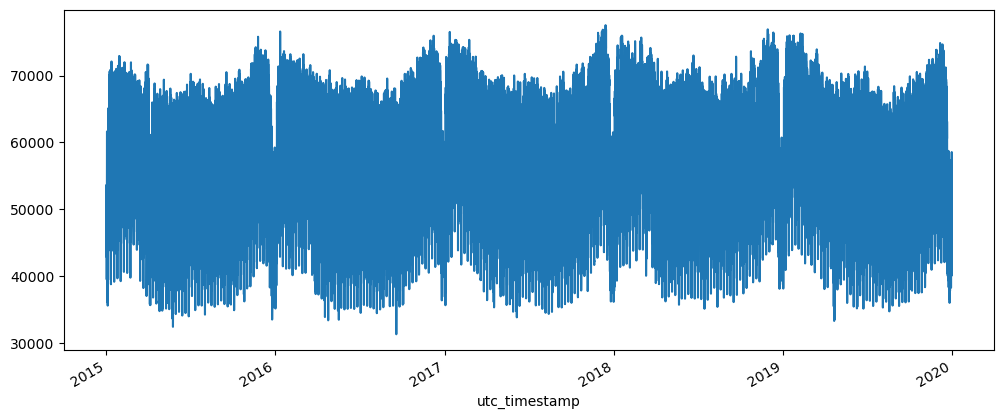

In [20]:
df["DE_load_actual_entsoe_transparency"].plot(figsize=(12,5))

<Axes: xlabel='utc_timestamp'>

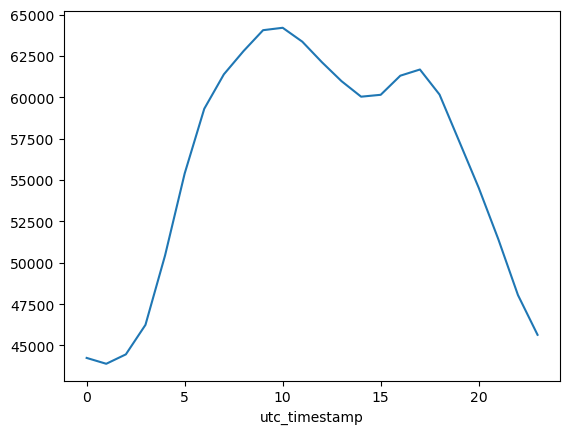

In [21]:
df.groupby(df.index.hour)["DE_load_actual_entsoe_transparency"].mean().plot()

In [22]:
df.corr()

,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,BE_wind_onshore_generation_actual,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,...,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile,FR_load_actual_entsoe_transparency,FR_load_forecast_entsoe_transparency,FR_solar_generation_actual,FR_wind_onshore_generation_actual
BE_load_actual_entsoe_transparency,1.000000,0.977062,0.167967,0.014210,0.000829,0.027811,0.900405,0.893450,-0.097039,0.181218,...,-0.106593,0.014944,0.075594,-0.081594,0.074565,0.093201,0.826733,0.819018,0.234948,0.061877
BE_load_forecast_entsoe_transparency,0.977062,1.000000,0.200005,0.077508,0.059680,0.087279,0.906235,0.903140,-0.060265,0.198924,...,-0.069575,0.054333,0.097923,-0.046006,0.119811,0.130163,0.817319,0.811475,0.253970,0.115021
BE_solar_generation_actual,0.167967,0.200005,1.000000,-0.156052,-0.137136,-0.155899,0.312810,0.334058,0.033050,0.913998,...,0.013899,-0.130952,-0.157825,0.028720,-0.167815,-0.172331,-0.059446,-0.054743,0.882766,-0.164792
BE_wind_generation_actual,0.014210,0.077508,-0.156052,1.000000,0.944028,0.922837,0.075438,0.075318,0.263947,-0.142055,...,0.266012,0.477188,0.373165,0.236060,0.640467,0.590388,0.124993,0.123637,-0.087355,0.756235
BE_wind_offshore_generation_actual,0.000829,0.059680,-0.137136,0.944028,1.000000,0.744122,0.070448,0.067127,0.321650,-0.125531,...,0.321601,0.470673,0.327851,0.279633,0.522719,0.458639,0.093058,0.091757,-0.070270,0.624851
BE_wind_onshore_generation_actual,0.027811,0.087279,-0.155899,0.922837,0.744122,1.000000,0.070513,0.074149,0.158949,-0.141105,...,0.163188,0.416785,0.372894,0.151535,0.686683,0.660089,0.144471,0.143243,-0.094856,0.801875
DE_load_actual_entsoe_transparency,0.900405,0.906235,0.312810,0.075438,0.070448,0.070513,1.000000,0.978837,0.030654,0.323092,...,0.038520,0.083287,0.071566,0.049242,0.100400,0.090739,0.645130,0.637448,0.381437,0.079190
DE_load_forecast_entsoe_transparency,0.893450,0.903140,0.334058,0.075318,0.067127,0.074149,0.978837,1.000000,0.018953,0.347928,...,0.028357,0.071870,0.061492,0.046181,0.087741,0.078819,0.638277,0.630089,0.404236,0.087241
DE_solar_capacity,-0.097039,-0.060265,0.033050,0.263947,0.321650,0.158949,0.030654,0.018953,1.000000,0.035573,...,0.975333,0.438840,-0.069125,0.936405,0.177014,-0.012989,-0.062472,-0.061403,0.105326,0.275811
DE_solar_generation_actual,0.181218,0.198924,0.913998,-0.142055,-0.125531,-0.141105,0.323092,0.347928,0.035573,1.000000,...,0.018556,-0.117575,-0.145248,0.034452,-0.171939,-0.176571,-0.071361,-0.069279,0.892511,-0.160868


In [23]:
X = df.drop(columns=["DE_load_actual_entsoe_transparency"])
y = df["DE_load_actual_entsoe_transparency"]

**Train**

In [24]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df["DE_load_actual_entsoe_transparency"], order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=24)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressiv

**EVALUATE THE MODEL**

In [1]:
import tensorflow as tf



In [3]:
tf.keras.layers.Dense(10, activation="relu")

AttributeError: module 'tensorflow' has no attribute 'keras'

In [4]:
one_layer_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), input_shape=input_shape, activation='relu'),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

AttributeError: module 'tensorflow' has no attribute 'keras'